# 01. ROSE and LROM for a Single Scattering Wavefunction

This notebook introduces the
`lrom` package. It compares high-fidelity solutions of the nuclear
scattering equation with ROSE/RBM and LROM approximations for the
exact $l=0$ channel of $^{40}$Ca(n,n) at 14.1 MeV. Treating the Least Squares (LS) floor as the benchmark.

The physical radius $r$ is in fm. LROM uses the public v1.2 `lrom` package.
ROSE and LROM use the same high-fidelity training snapshots,
but they use different reference solutions: LROM is centered on the central
potential solution, while ROSE is centered on the free solution commonly used for the reduced-basis equation. Emulated wavefunctions are compared for all methods to illustrate the performance of LROM. Usage of the `lrom` package are illustrated.



Comparison between benchmark and LROM examples:

- `vv_emulator`: `ws_1`, a Vv-only linspace study with normalized parameter predictors.
- `ws3_emulator`: `ws_3`, a Vv/Rv/av Latin-hypercube study with six selected potential predictors.


In [ ]:
#Required Packages
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from numba import njit
import numpy as np
import pandas as pd

from scipy.interpolate import LinearNDInterpolator

#Checking directory
ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name in ("lrom", "lrom_legacy") or name.startswith(("lrom.", "lrom_legacy.")):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [2]:
#importing relevant libraries for LROM and ROSE
import rose
import lrom

print("LROM package:", lrom.__version__)


LROM package: 1.2.0


## Section 1. Parameter Varying Vv

The first emulator (object) has a testing interval wider than its training interval. With fixed
$R_v$ and $a_v$ values from the Koning-Delaroche global optical potential. Target/projectile system is at 14.1 MeV laboratory
energy; where only $V_v$ will vary.

In [3]:

#Setting up 
BASIS_SIZE = 4
DISPLAY_ERROR_FLOOR = 1e-11
METHOD_COLORS = {"ls": "blue", "lrom": "#E6AB02", "rose": "red"}

#setting up emulator object, initializing system of interest
vv_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_1",
)
#Setting central values, defining training and testing ranges
vv_center = dict(vv_emulator.central_parameters)
Vv0 = vv_center["Vv"]
vv_training_ranges = {"Vv": (0.90 * Vv0, 1.10 * Vv0)}
vv_testing_ranges = {"Vv": (0.65 * Vv0, 1.35 * Vv0)}

# generating sampled varying Vv HFS solutions
vv_emulator.sampling(
    training_ranges=vv_training_ranges,
    testing_ranges=vv_testing_ranges,
    training_size=35,
    testing_size=41,
    mesh_size=800,
    strategy="linspace",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Training RF-LROM with 1 predcitor
vv_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=1,
)

### Using ROSE, and Initializing LS

To benchmark LROM to ROSE and the True solution LS

In [4]:
# We pull samples from lrom.sample to run ROSE and the true solution LS

vv_samples = vv_emulator.samples
vv_fom_train = vv_samples.training_wavefunctions[0]
vv_fom_test = vv_samples.testing_wavefunctions[0]


#Producing LS solutions
vv_ls_train_coefficients, vv_ls_train_wavefunctions = lrom.least_squares_baseline(basis=vv_emulator.basis[0], wavefunctions=vv_fom_train)
vv_ls_coefficients, vv_ls_wavefunctions = lrom.least_squares_baseline(basis=vv_emulator.basis[0], wavefunctions=vv_fom_test)
vv_ls_relative_l2 = lrom.relative_l2(prediction=vv_ls_wavefunctions, reference=vv_fom_test)

for k, v in {
    "central parameters": dict(vv_emulator.central_parameters),
    "fixed Rv [fm]": vv_center["Rv"],
    "fixed av [fm]": vv_center["av"],
    "training wavefunctions": vv_fom_train.shape,
    "testing wavefunctions": vv_fom_test.shape,
}.items():
    print(f"{k}: {v}")


# Producing ROSE solutions
import rose_helper # Calling helper function to run ROSE pipeline

vv_rose = rose_helper.build_rose(vv_emulator, vv_center,BASIS_SIZE,eim_basis=8, emulate_train_wf=False)

# Aliases so the existing plotting cells keep working unchanged.
vv_train_rows, vv_test_rows = vv_rose.train_rows, vv_rose.test_rows
vv_rose_basis = vv_rose.basis
vv_rose_train_coefficients = vv_rose.train_coefficients
vv_rose_coefficients = vv_rose.coefficients
vv_rose_wavefunctions = vv_rose.wf_test

central parameters: {'Vv': np.float64(48.822175142383706), 'Rv': np.float64(4.053875273743491), 'av': np.float64(0.671852)}
fixed Rv [fm]: 4.053875273743491
fixed av [fm]: 0.671852
training wavefunctions: (35, 800)
testing wavefunctions: (41, 800)


The potential rainbow shows the varying of Vv, while the
wavefunction rainbow shows corresponding sample range.

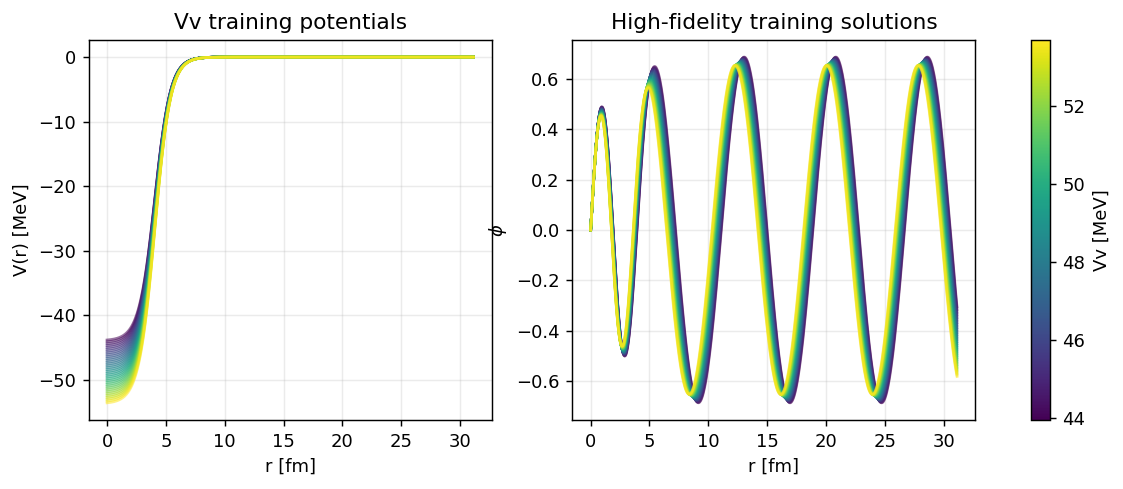

In [5]:
# Vv training potentials + high-fidelity solutions, colored by sample value
r = vv_emulator.mesh.radius
vv_values = vv_emulator.samples.design.training.values[:, 0]
norm = plt.Normalize(vv_values.min(), vv_values.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
data = [
    (axes[0], vv_emulator.samples.training_potentials, "V(r) [MeV]", "Vv training potentials"),
    (axes[1], vv_emulator.samples.training_wavefunctions[0], r"$\phi$", "High-fidelity training solutions"),
]

for ax, curves, ylabel, title in data:
    for v, y in zip(vv_values, curves):
        ax.plot(r, y.real, color=plt.cm.viridis(norm(v)), alpha=0.55)
    ax.set(xlabel="r [fm]", ylabel=ylabel, title=title)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, label="Vv [MeV]")
plt.show()

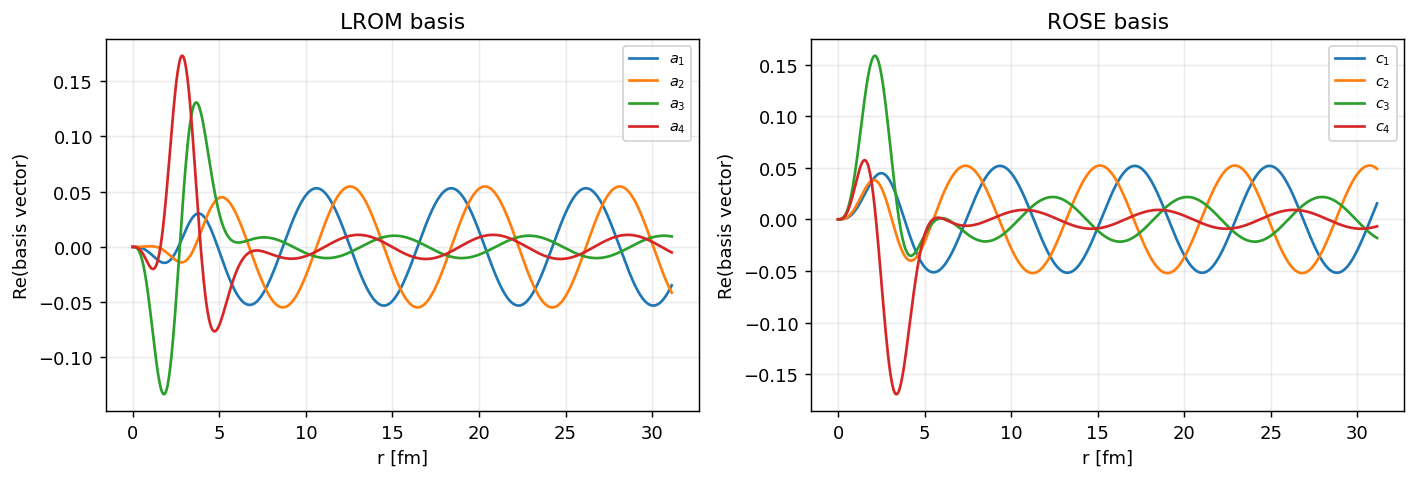

In [6]:
# Sect 1: LROM vs ROSE reduced bases
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
pairs = [(vv_emulator.basis[0], "LROM", "a"), (vv_rose_basis, "ROSE", "c")]

for ax, (basis, name, sym) in zip(axes, pairs):
    for i in range(BASIS_SIZE):
        ax.plot(r, np.real(basis.vectors[:, i]), label=fr"${sym}_{{{i+1}}}$")
    ax.set(xlabel="r [fm]", ylabel="Re(basis vector)", title=f"{name} basis")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()



### Coefficients (Coordinates for training and testing)

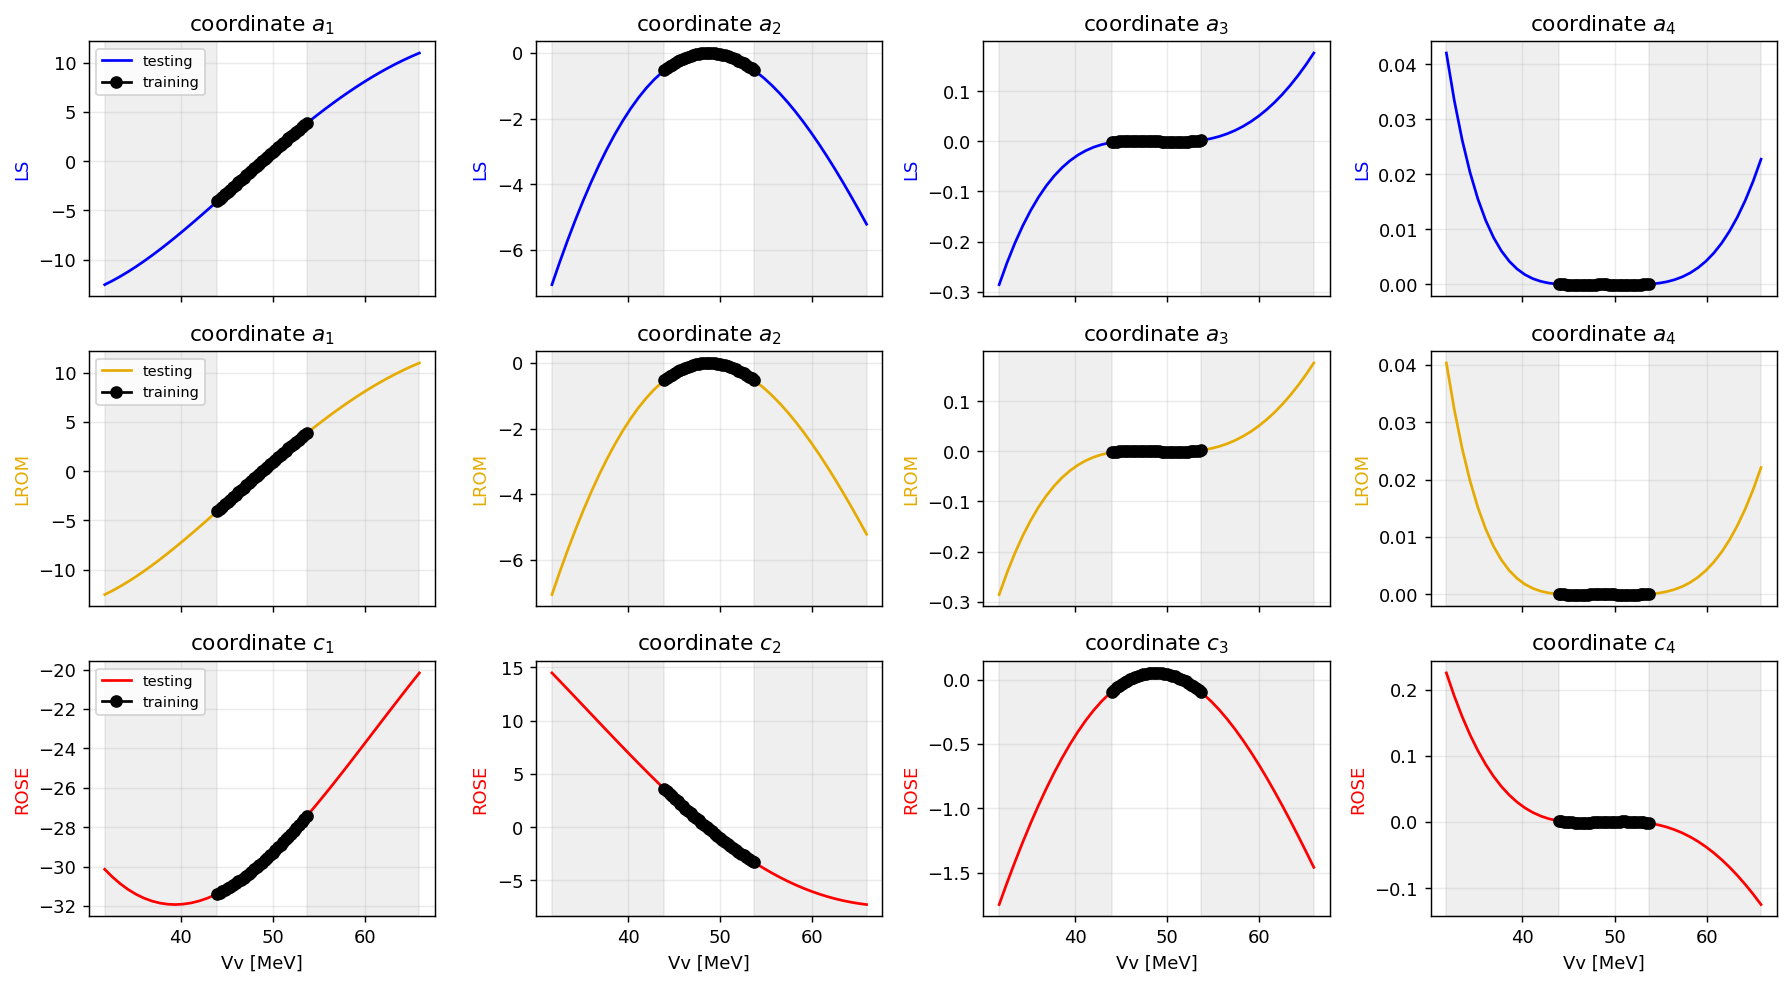

In [7]:
vv_train = vv_train_rows[:, 0]
vv_test = vv_test_rows[:, 0]
mask = ~np.isclose(vv_test, Vv0, rtol=0.0, atol=1e-12)
lo, hi = vv_training_ranges["Vv"]

vv_coordinate_data = [
    ("LS", vv_ls_train_coefficients, vv_ls_coefficients, "a", METHOD_COLORS["ls"]),
    ("LROM",
     np.asarray(vv_emulator.training_results.coefficients["lrom"][0]),
     np.asarray(vv_emulator.testing_results.coefficients["lrom"][0]),
     "a", METHOD_COLORS["lrom"]),
    ("ROSE", vv_rose_train_coefficients, vv_rose_coefficients, "c", METHOD_COLORS["rose"]),
]

fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14, 8), sharex="col")
last = len(vv_coordinate_data) - 1

for i, (method, train_c, test_c, sym, color) in enumerate(vv_coordinate_data):
    for j in range(BASIS_SIZE):
        ax = axes[i, j]
        first = j == 0
        ax.plot(vv_test[mask], test_c[mask, j].real, color=color,
                label="testing" if first else None)
        ax.plot(vv_train, train_c[:, j].real, marker="o", color="black",
                label="training" if first else None)
        ax.axvspan(vv_test.min(), lo, color="gray", alpha=0.12)
        ax.axvspan(hi, vv_test.max(), color="gray", alpha=0.12)
        ax.set_title(fr"coordinate ${sym}_{{{j+1}}}$")
        ax.set_ylabel(method, color=color)
        if i == last:
            ax.set_xlabel("Vv [MeV]")
    axes[i, 0].legend(fontsize=8)

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

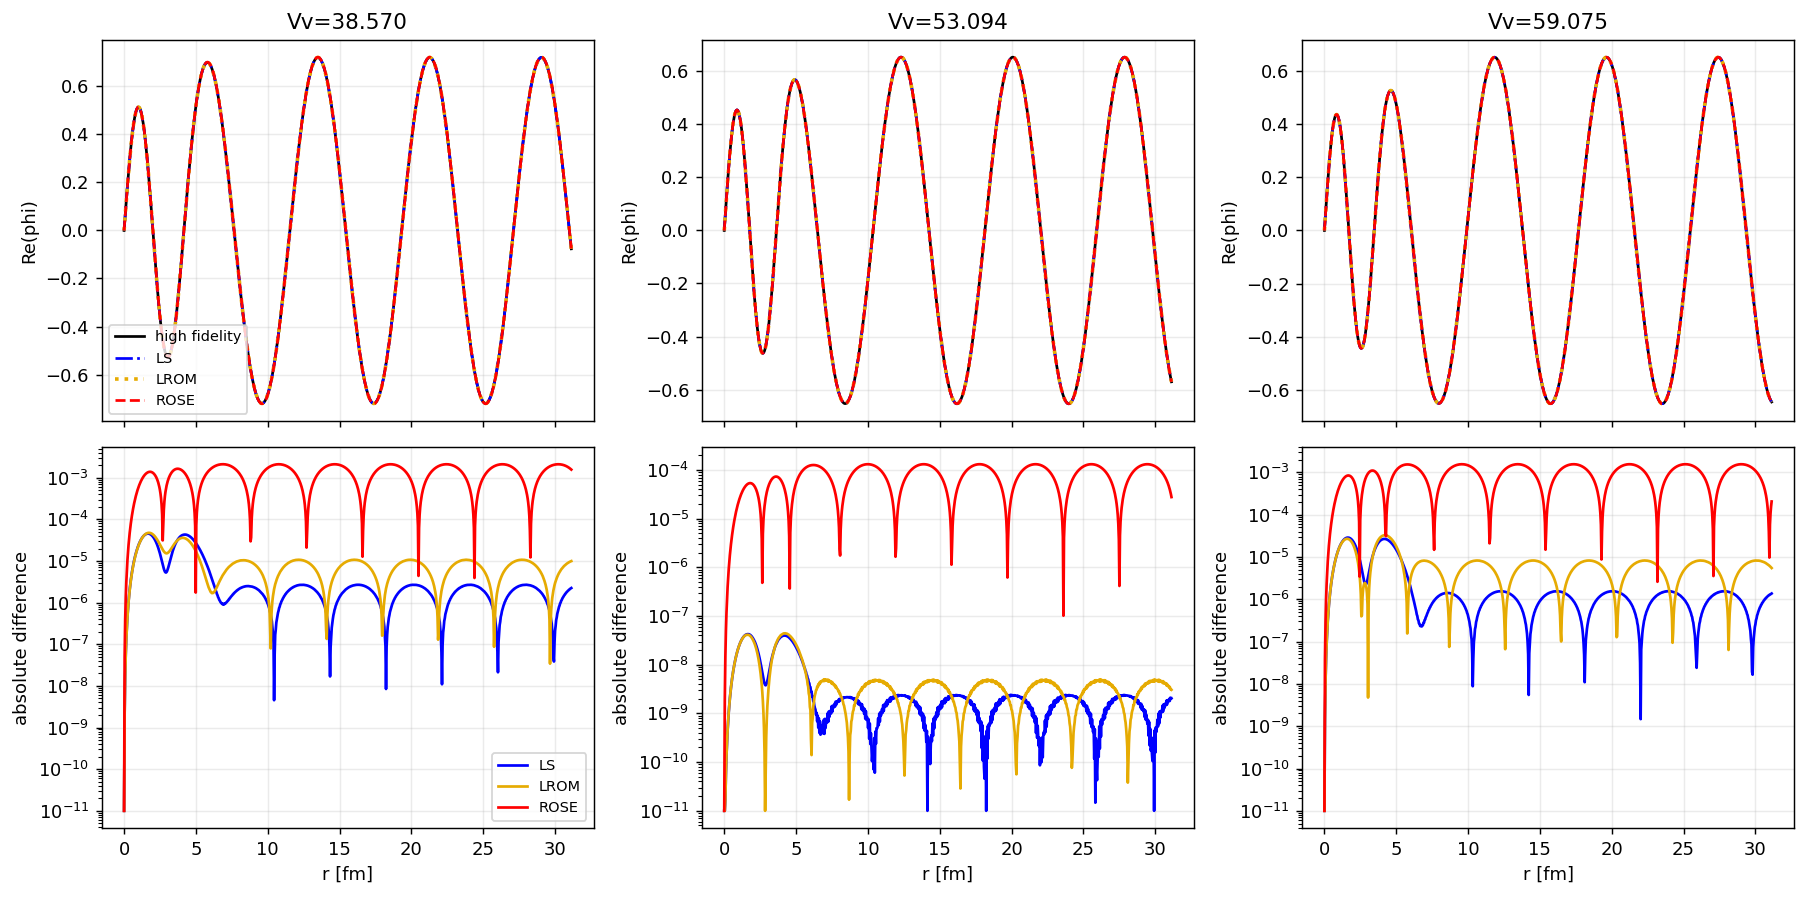

In [8]:
# Eligible cases: away from the central reference, and not overlapping training points.
vv_half_range = 0.5 * (vv_testing_ranges["Vv"][1] - vv_testing_ranges["Vv"][0])
vv_normalized_distance = np.abs(vv_test - Vv0) / vv_half_range
vv_training_overlap = np.any(
    np.isclose(vv_test[:, None], vv_train[None, :], rtol=0.0, atol=1e-12),
    axis=1,
)
vv_eligible = np.flatnonzero((vv_normalized_distance >= 0.25) & ~vv_training_overlap)
assert len(vv_eligible) >= 3

# Pick three eligible cases spread across the Vv range.
vv_sorted = vv_eligible[np.argsort(vv_test[vv_eligible])]
vv_positions = np.rint(np.array([0.25, 0.50, 0.75]) * (len(vv_sorted) - 1)).astype(int)
vv_selected_indices = vv_sorted[vv_positions]
assert len(np.unique(vv_selected_indices)) == 3

vv_case_ids = np.asarray(vv_emulator.samples.design.testing.case_ids)

fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0), sharex="col")
for column, selected_index in enumerate(vv_selected_indices):
    vv_case = vv_emulator.testing_case(case_id=vv_case_ids[selected_index])
    reference = vv_case.high_fidelity[0]
    methods = (
        ("LS", vv_ls_wavefunctions[selected_index], "ls", "-.", None),
        ("LROM", vv_case.lrom[0], "lrom", ":", 2),
        ("ROSE", vv_rose_wavefunctions[selected_index], "rose", "--", None),
    )

    axes[0, column].plot(vv_case.radius, np.real(reference), color="black", label="high fidelity")
    for name, prediction, key, style, width in methods:
        axes[0, column].plot(
            vv_case.radius, np.real(prediction), style,
            color=METHOD_COLORS[key], linewidth=width, label=name,
        )
        axes[1, column].plot(
            vv_case.radius,
            np.maximum(np.abs(reference - prediction), DISPLAY_ERROR_FLOOR),
            color=METHOD_COLORS[key], label=name,
        )
    axes[0, column].set(ylabel="Re(phi)", title=f"Vv={vv_test[selected_index]:.3f}")
    axes[1, column].set(xlabel="r [fm]", ylabel="absolute difference")
    axes[1, column].set_yscale("log")

axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

NameError: name 'vv_plot_mask' is not defined

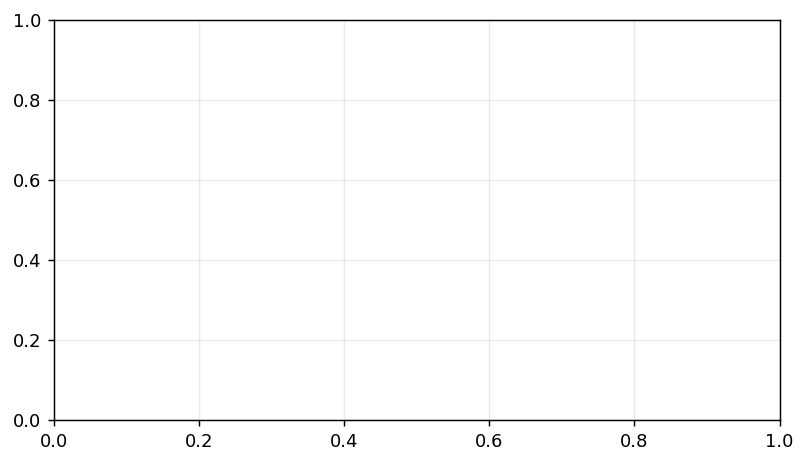

In [10]:
vv_errors = dict(vv_emulator.testing_errors[0])
vv_errors["ls"] = np.abs(vv_ls_wavefunctions - vv_fom_test)
vv_errors["rose"] = np.abs(vv_rose_wavefunctions - vv_fom_test)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method in ("rose", "lrom", "ls"):
    for error in vv_errors[method][vv_plot_mask]:
        ax.plot(r, np.maximum(error, DISPLAY_ERROR_FLOOR), color=METHOD_COLORS[method], alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("r [fm]")
ax.set_ylabel("absolute difference")
ax.set_title("Vv-only testing errors for ROSE, LROM, and LS")
plt.show()

## Section 2. Varied three parameters for the woods saxon potential

The second object varies Vv, Rv, and av. Potential predictors are selected values from the Woods-Saxon potential which are determined from the maxvol algorithim.

The LROM equation:
$(I + \sum_{j=1}^{J}p_j(\alpha)M_j)a(\alpha)
= \sum_{j=1}^{J}p_j(\alpha)b_j$, where $\alpha=(V_v,R_v,a_v)$

1. We first set up the configuration for the system, defining the projectile, lab energy, potential of interest, and etc. Then move into `sampling`, ``, ``

2. We then find the predictors


In [ ]:
# initializing config object
ws3_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_3",
)

#Constructing training and testing ranges

ws3_center = dict(ws3_emulator.central_parameters)
ws3_training_ranges = {
    name: (0.90 * ws3_center[name], 1.10 * ws3_center[name])
    for name in ("Vv", "Rv", "av")
}
ws3_testing_ranges = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

# generating samples, varying 3 parameters, and producing HFS solutions
ws3_emulator.sampling(
    training_ranges=ws3_training_ranges,
    testing_ranges=ws3_testing_ranges,
    training_size=70,
    testing_size=81,
    mesh_size=800, 
    strategy="latin_hypercube",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Training LROM with 3 predictors
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=3,
)

# Showing results and comparing to exact solution
parameter_lrom = np.asarray(ws3_emulator.testing_results.lrom[0]).copy()

parameter_relative_l2 = np.asarray( ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"] ).copy()
parameter_training_relative_l2 = np.asarray( ws3_emulator.training_results.metrics["relative_l2"][0]["lrom"] ).copy()

# Training with 3 predictors
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=3,
)


The radi show selected local potential values which become LROM
predictor features. The gray curves represent this selection.

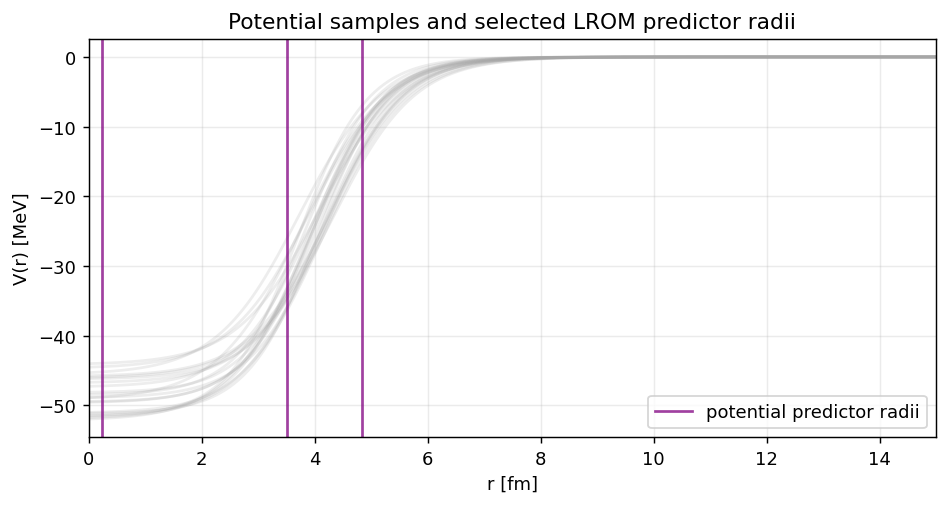

In [ ]:
r3 = ws3_emulator.mesh.radius
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for potential in ws3_emulator.samples.training_potentials[:20]:
    ax.plot(r3, np.real(potential), color="0.65", alpha=0.20)
for radius_index, selected_radius in enumerate(
    ws3_emulator.predictors.selected_radii, start=1
):
    ax.axvline(
        selected_radius,
        color="purple",
        alpha=0.75,
        label="potential predictor radii" if radius_index == 1 else None,
    )
ax.set(
    xlabel="r [fm]",
    ylabel="V(r) [MeV]",
    title="Potential samples and selected LROM predictor radii",
)
ax.legend()
plt.xlim(0,15)
fig.tight_layout()
plt.show()

### Constructing LS Floor and ROSE benchmark solutions for varying 3 parameters

In [ ]:
ws3_fom_train = ws3_emulator.samples.training_wavefunctions[0]
ws3_fom_test = ws3_emulator.samples.testing_wavefunctions[0]

ws3_ls_train_coefficients, ws3_ls_wf_train = lrom.least_squares_baseline(basis=ws3_emulator.basis[0], wavefunctions=ws3_fom_train)

ws3_ls_coefficients, ws3_ls_wf_test = lrom.least_squares_baseline(basis=ws3_emulator.basis[0], wavefunctions=ws3_fom_test)
ws3_ls_rel_train = lrom.relative_l2(prediction=ws3_ls_wf_train, reference=ws3_fom_train)
ws3_ls_rel_test = lrom.relative_l2(prediction=ws3_ls_wf_test, reference=ws3_fom_test)

ws3_rose = rose_helper.build_rose(ws3_emulator, ws3_center,BASIS_SIZE,eim_basis=8)

ws3_train_rows, ws3_test_rows = ws3_rose.train_rows, ws3_rose.test_rows
ws3_rose_basis = ws3_rose.basis
ws3_rose_train_coefficients = ws3_rose.train_coefficients
ws3_rose_coefficients = ws3_rose.coefficients
ws3_rose_wf_train, ws3_rose_wf_test = ws3_rose.wf_train, ws3_rose.wf_test
ws3_rose_rel_train = np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1) / np.linalg.norm(ws3_fom_train, axis=1)
ws3_rose_rel_test = np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1) / np.linalg.norm(ws3_fom_test, axis=1)

print("potential predictor radii [fm]:", ws3_emulator.predictors.selected_radii)

potential predictor radii [fm]: [3.50667701 4.83142165 0.23377848]


Here we compare the reduced basis of ROSE and LROM

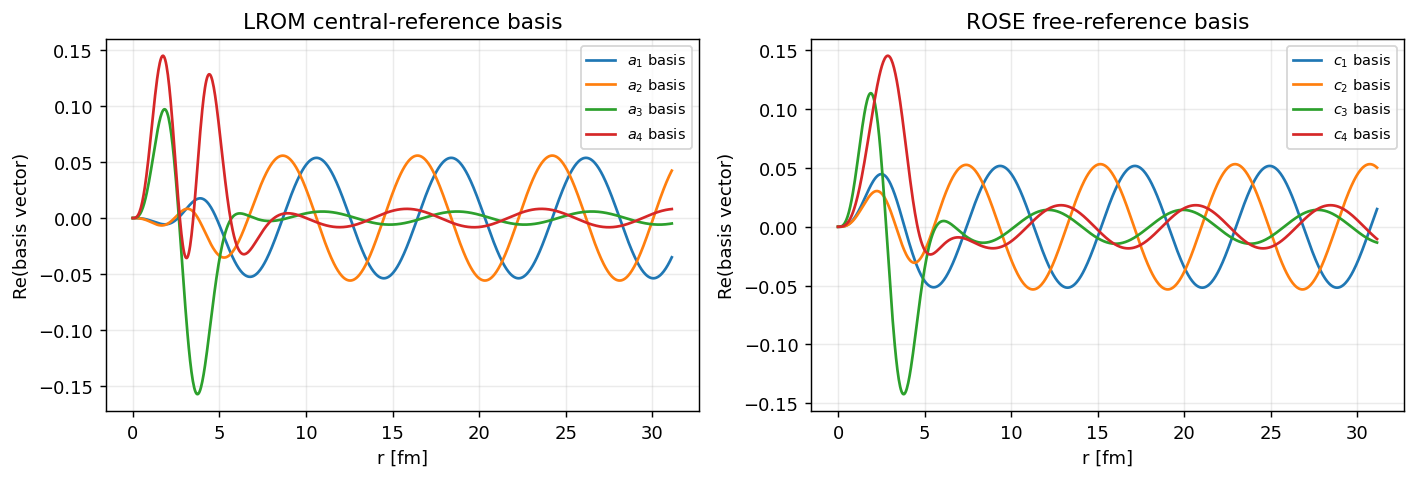

In [ ]:
ws3_basis = ws3_emulator.basis[0]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))

for coordinate_index in range(BASIS_SIZE):
    axes[0].plot(r3,np.real(ws3_basis.vectors[:, coordinate_index]),
        label=fr"$a_{{{coordinate_index + 1}}}$ basis",)
    
    axes[1].plot(r3,np.real(ws3_rose_basis.vectors[:, coordinate_index]),
        label=fr"$c_{{{coordinate_index + 1}}}$ basis",)
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="LROM central-reference basis",
)
axes[1].set(xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ROSE free-reference basis",
)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Plotted are the coefficients for all methods

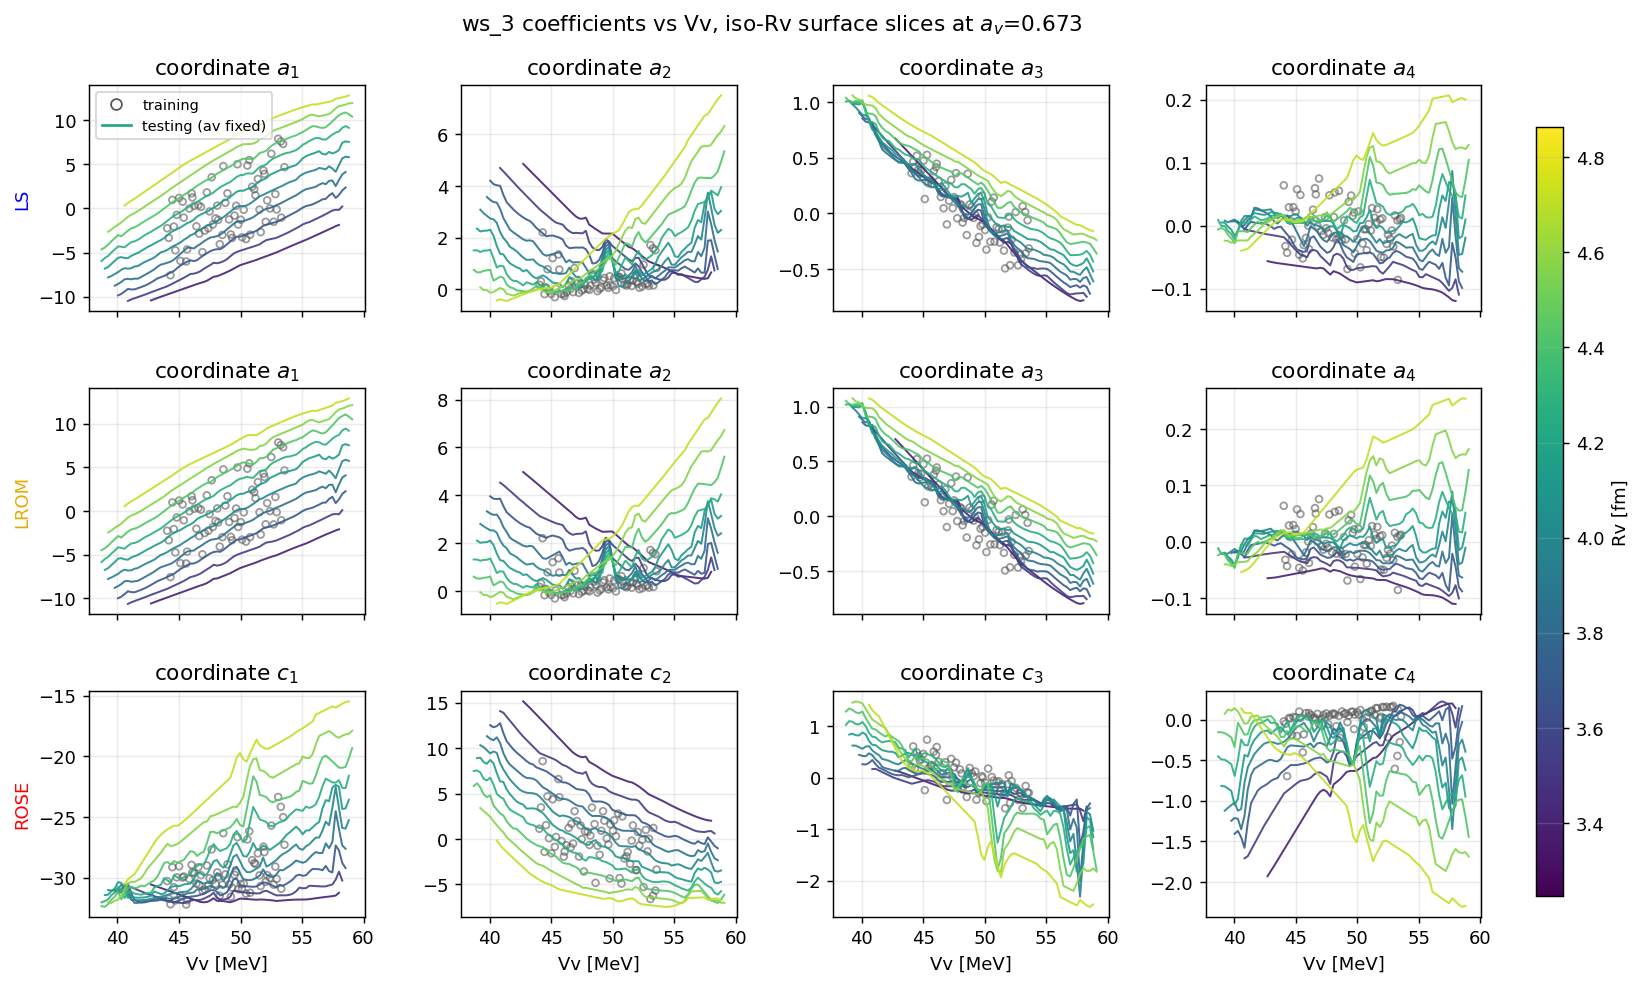

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


ws3_coordinate_data = {
    "LS":   {"training": ws3_ls_train_coefficients,
             "testing":  ws3_ls_coefficients,   "symbol": "a", "color": METHOD_COLORS["ls"]},
    "LROM": {"training": np.asarray(ws3_emulator.training_results.coefficients["lrom"][0]),
             "testing":  np.asarray(ws3_emulator.testing_results.coefficients["lrom"][0]),
             "symbol": "a", "color": METHOD_COLORS["lrom"]},
    "ROSE": {"training": ws3_rose_train_coefficients,
             "testing":  ws3_rose_coefficients, "symbol": "c", "color": METHOD_COLORS["rose"]},
}

# Surface a(Vv, Rv, av): fix av at center, trace iso-Rv lines across Vv.
cmap = plt.cm.viridis
params = ws3_test_rows[:, :3]                      # columns: Vv, Rv, av
av_fixed = np.median(ws3_test_rows[:, 2])

n_lines = 12
vv_grid = np.linspace(ws3_test_rows[:, 0].min(), ws3_test_rows[:, 0].max(), 80)
rv_lines = np.linspace(ws3_test_rows[:, 1].min(), ws3_test_rows[:, 1].max(), n_lines)
ws3_rv_norm = plt.Normalize(rv_lines.min(), rv_lines.max())

fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14.0, 8.0), sharex="col")
for row_index, (method, data) in enumerate(ws3_coordinate_data.items()):
    for coordinate_index in range(BASIS_SIZE):
        ax = axes[row_index, coordinate_index]
        values = np.real(data["testing"][:, coordinate_index])
        interp = LinearNDInterpolator(params, values)   # smooth surface fit

        for rv in rv_lines:
            query = np.column_stack([vv_grid, np.full_like(vv_grid, rv),
                                     np.full_like(vv_grid, av_fixed)])
            y = interp(query)                            # NaN outside the data hull -> gaps
            ax.plot(vv_grid, y, color=cmap(ws3_rv_norm(rv)), linewidth=1.1, alpha=0.9)

        ax.scatter(
            ws3_train_rows[:, 0], np.real(data["training"][:, coordinate_index]),
            s=14, marker="o", facecolors="none", edgecolors="0.35", alpha=0.6,
        )
        ax.set_title(fr"coordinate ${data['symbol']}_{{{coordinate_index + 1}}}$")
        if coordinate_index == 0:
            ax.set_ylabel(method, color=data["color"])
        if row_index == 2:
            ax.set_xlabel("Vv [MeV]")

axes[0, 0].legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor="none", markeredgecolor="0.35", label="training"),
        Line2D([0], [0], color=cmap(0.6), linewidth=1.5, label="testing (av fixed)"),
    ],
    fontsize=8,
)

fig.subplots_adjust(top=0.91, right=0.89, hspace=0.34, wspace=0.35)
cbar_ax = fig.add_axes([0.92, 0.13, 0.015, 0.74])
fig.colorbar(plt.cm.ScalarMappable(norm=ws3_rv_norm, cmap=cmap), cax=cbar_ax, label="Rv [fm]")
fig.suptitle(fr"ws_3 coefficients vs Vv, iso-Rv surface slices at $a_v$={av_fixed:.3f}")
plt.show()

## Section 3. Three Param Emulation Results

We choose three ws_3 cases, mimicing the method for Vv.


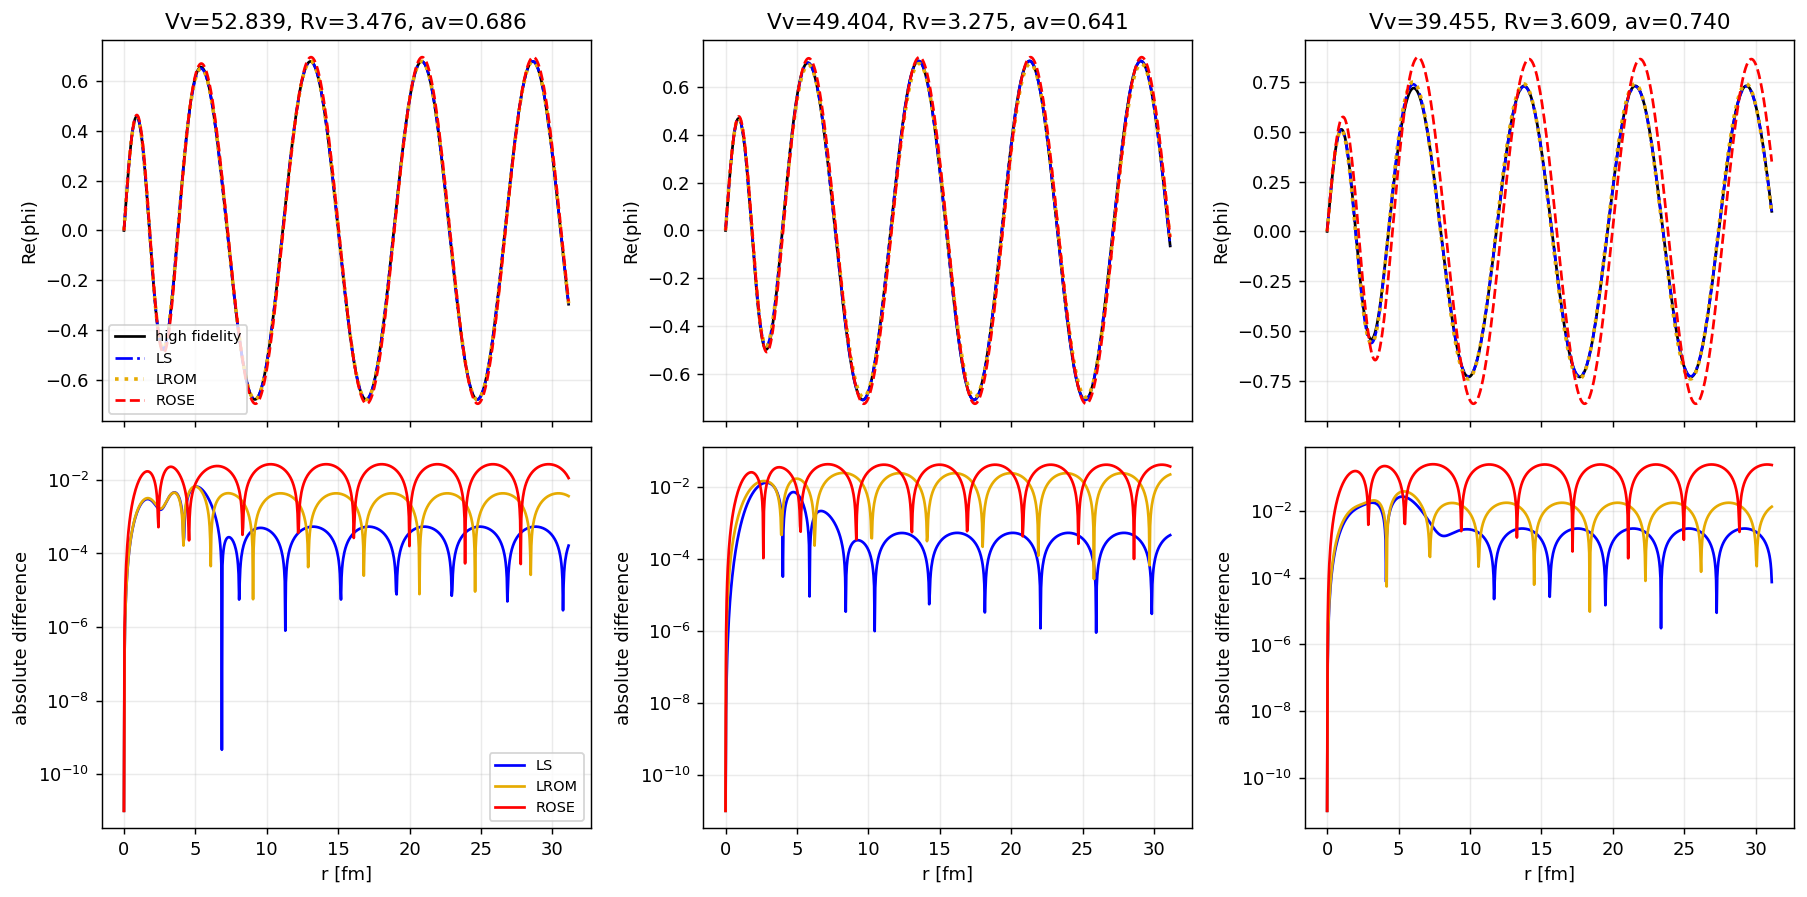

In [ ]:

ws3_half_ranges = np.asarray([
    0.5 * (ws3_testing_ranges[name][1] - ws3_testing_ranges[name][0])
    for name in ws3_emulator.parameter_names
])
ws3_center_row = np.asarray([ws3_center[name] for name in ws3_emulator.parameter_names])
ws3_normalized_distance = np.linalg.norm(
    (ws3_test_rows - ws3_center_row) / ws3_half_ranges, axis=1
)
ws3_training_overlap = np.any(
    np.all(
        np.isclose(
            ws3_test_rows[:, None, :], ws3_train_rows[None, :, :],
            rtol=0.0, atol=1e-12,
        ),
        axis=2,
    ),
    axis=1,
)
ws3_eligible = np.flatnonzero((ws3_normalized_distance >= 0.25) & ~ws3_training_overlap)
assert len(ws3_eligible) >= 3

# Pick three eligible cases spread across their distance from center.
ws3_sorted = ws3_eligible[np.argsort(ws3_normalized_distance[ws3_eligible])]
ws3_positions = np.rint(np.array([0.25, 0.50, 0.75]) * (len(ws3_sorted) - 1)).astype(int)
ws3_selected_indices = ws3_sorted[ws3_positions]
assert len(np.unique(ws3_selected_indices)) == 3

ws3_case_ids = np.asarray(ws3_emulator.samples.design.testing.case_ids)

fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0), sharex="col")
for column, selected_index in enumerate(ws3_selected_indices):
    ws3_case = ws3_emulator.testing_case(case_id=ws3_case_ids[selected_index])
    reference = ws3_case.high_fidelity[0]
    methods = (
        ("LS", ws3_ls_wf_test[selected_index], "ls", "-.", None),
        ("LROM", ws3_case.lrom[0], "lrom", ":", 2),
        ("ROSE", ws3_rose_wf_test[selected_index], "rose", "--", None),
    )

    axes[0, column].plot(ws3_case.radius, np.real(reference), color="black", label="high fidelity")
    for name, prediction, key, style, width in methods:
        axes[0, column].plot(
            ws3_case.radius, np.real(prediction), style,
            color=METHOD_COLORS[key], linewidth=width, label=name,
        )
        axes[1, column].plot(
            ws3_case.radius,
            np.maximum(np.abs(reference - prediction), DISPLAY_ERROR_FLOOR),
            color=METHOD_COLORS[key], label=name,
        )
    parameter_text = ", ".join(
        f"{name}={value:.3f}"
        for name, value in zip(ws3_emulator.parameter_names, ws3_test_rows[selected_index])
    )
    axes[0, column].set(ylabel="Re(phi)", title=parameter_text)
    axes[1, column].set(xlabel="r [fm]", ylabel="absolute difference")
    axes[1, column].set_yscale("log")

axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### Violin plots capturing the performance of each method, LS being the benchmark. Note LROM is using 6 Predictors

In [ ]:
# Creating a dictionary that stores all training and testing metric values
methods = ("ls", "lrom", "rose")
colors = tuple(METHOD_COLORS[method] for method in methods)
positions = np.arange(1, 4)
training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["ls"] = ws3_ls_rel_train
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["ls"] = ws3_ls_rel_test
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.maximum(training_metrics[method], np.finfo(float).tiny)
    for method in methods
]
testing_values = [
    np.maximum(testing_metrics[method], np.finfo(float).tiny)
    for method in methods
]

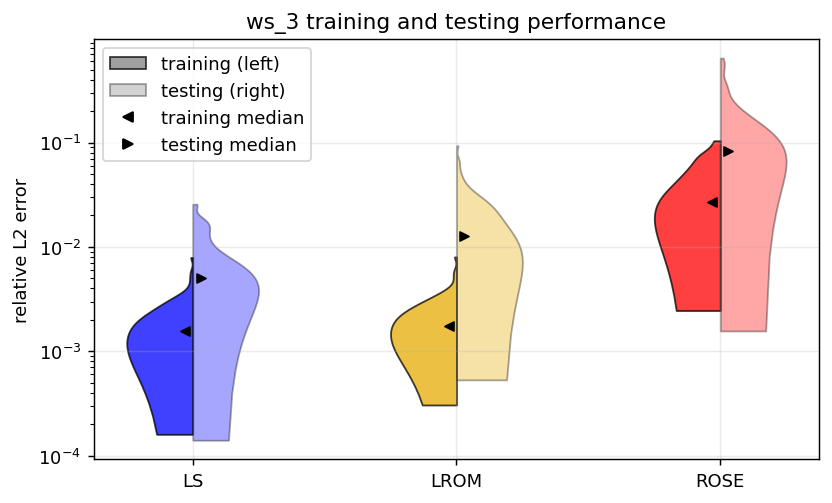

In [ ]:

fig, ax = plt.subplots(figsize=(7.2, 4.2))
training_violin = ax.violinplot(training_values, positions=positions,showextrema=False,)
testing_violin = ax.violinplot(testing_values, positions=positions, showextrema=False,)

for center, body, color in zip(positions, training_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.minimum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)

for center, body, color in zip(positions, testing_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.maximum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)

ax.scatter(positions - 0.03, [np.median(values) for values in training_values], color="black", marker="<", s=24)
ax.scatter(positions + 0.03, [np.median(values) for values in testing_values], color="black", marker=">", s=24)
ax.set_xticks(positions, [method.upper() for method in methods])
ax.set_yscale("log")
ax.set_ylabel("relative L2 error")
ax.set_title("ws_3 training and testing performance")
ax.legend(handles=[
    Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="training (left)"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="testing (right)"),
    Line2D([], [], color="black", marker="<", linestyle="None", label="training median"),
    Line2D([], [], color="black", marker=">", linestyle="None", label="testing median"),
])
plt.show()

### Saving parameters from trained emulator, along with full emulator object.

In [ ]:
artifact_path = ROOT / "outputs" / "notebook01_ws3_model.lrom"
ws3_emulator.save(path=artifact_path)
portable_emulator = lrom.load(path=artifact_path)
ws3_export_case = ws3_emulator.testing_case(
    case_id=ws3_selected_ids[1]
)
portable_emulator.predict(parameters=ws3_export_case.parameters)
print("portable model:", artifact_path)
print("prediction shape:", portable_emulator.predictions.wavefunctions[0].shape)

portable model: /Users/Kitkat/Documents/Documents-Agent/LROM_Project/outputs/notebook01_ws3_model.lrom
prediction shape: (1, 800)
